CIT-227-024/2024 KYALE JAPETH

CCS 2226 - Foundations of AI (2026)

Task One: MNIST Digit Recognition (0-9)

In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras


In [3]:
# Load MNIST dataset (handwritten digits 0–9)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to range [0, 1]
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# Flatten 28x28 images into 784‑dimensional vectors
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)


In [4]:
# Build the neural network
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),  # Hidden layer 1
    keras.layers.Dense(64, activation='relu'),                       # Hidden layer 2
    keras.layers.Dense(10, activation='softmax')                     # Output layer (10 classes)
])

# Compile the model with optimizer, loss function, and evaluation metric
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Train the model on the training data
model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1  # Use 10% of training data for validation
)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9246 - loss: 0.2557 - val_accuracy: 0.9685 - val_loss: 0.1139
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9659 - loss: 0.1081 - val_accuracy: 0.9722 - val_loss: 0.0925
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9764 - loss: 0.0755 - val_accuracy: 0.9748 - val_loss: 0.0837
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9818 - loss: 0.0564 - val_accuracy: 0.9793 - val_loss: 0.0777
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9853 - loss: 0.0451 - val_accuracy: 0.9747 - val_loss: 0.0885
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9881 - loss: 0.0354 - val_accuracy: 0.9775 - val_loss: 0.0905
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9904 - loss: 0.0294 - val_accuracy: 0.9813 - val_loss: 0.0894
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9917 - loss: 0.0251 -

In [6]:
# Evaluate model performance on the test dataset
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9772 - loss: 0.0865
Test Accuracy: 97.72%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


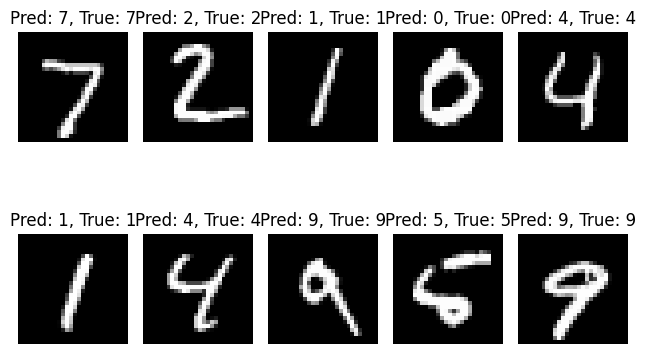

In [7]:
# Generate predictions for the first 10 test images
predictions = model.predict(x_test[:10])

# Plot the images with predicted and true labels
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {np.argmax(predictions[i])}, True: {y_test[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()
